
# Step 1 — Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

##  Set default visual style for all plots at once
plt.rcParams.update({
    "figure.dpi": 150,              # image sharpness 
    "font.family": "serif",         # change font in plots
    "axes.spines.top": False,       # remove the top border line around plot
    "axes.spines.right": False,     # remove the right border line around the plot
})

# Step 2 — Load raw files

In [2]:
# --- Hourly file (Jan 2020 – Sep 2025) ---
df_h = pd.read_excel(
    "../data/raw/hourly_original.xlsx",
    skiprows=9,          # skip SMARD metadata
    header=0,
    usecols=[0, 2],      # Start date + DE-LU price only
    names=["timestamp", "price_eur_mwh"],
)
 
# --- Quarter-hourly file (Oct 2025 – Feb 2026) ---
df_qh = pd.read_excel(
    "../data/raw/QuarterHourly.xlsx",
    skiprows=9,
    header=0,
    usecols=[0, 2],
    names=["timestamp", "price_eur_mwh"],
)
 
print("Hourly raw shape:        ", df_h.shape)
print("Quarter-hourly raw shape:", df_qh.shape)

C:\Users\ebteh\miniconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\ebteh\miniconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Hourly raw shape:         (50399, 2)
Quarter-hourly raw shape: (14500, 2)


# Step 3 — Fix data types

In [3]:
df_h["timestamp"]  = pd.to_datetime(df_h["timestamp"],  format="%b %d, %Y %I:%M %p")
df_qh["timestamp"] = pd.to_datetime(df_qh["timestamp"], format="%d.%m.%Y %H:%M")

df_h["price_eur_mwh"]  = pd.to_numeric(df_h["price_eur_mwh"],  errors="coerce")
df_qh["price_eur_mwh"] = pd.to_numeric(df_qh["price_eur_mwh"], errors="coerce")
    
print("Hourly dtypes:\n",        df_h.dtypes)
print("\nQuarter-hourly dtypes:\n", df_qh.dtypes)

Hourly dtypes:
 timestamp        datetime64[us]
price_eur_mwh           float64
dtype: object

Quarter-hourly dtypes:
 timestamp        datetime64[us]
price_eur_mwh           float64
dtype: object


# Step 4 — Check & fix duplicates

In [4]:
for name, df in [("Hourly", df_h), ("Quarter-hourly", df_qh)]:
    n_dupes = df.duplicated(subset="timestamp").sum()        #total number of duplicate rows found
    print(f"{name} — duplicate timestamps: {n_dupes}")
 
# Drop duplicates, keep first occurrence
df_h  = df_h.drop_duplicates(subset="timestamp").sort_values("timestamp").reset_index(drop=True)
df_qh = df_qh.drop_duplicates(subset="timestamp").sort_values("timestamp").reset_index(drop=True)
 
print("\nAfter deduplication:")
print("Hourly shape:        ", df_h.shape)
print("Quarter-hourly shape:", df_qh.shape)

Hourly — duplicate timestamps: 5
Quarter-hourly — duplicate timestamps: 4

After deduplication:
Hourly shape:         (50394, 2)
Quarter-hourly shape: (14496, 2)


# Step 5 — Check missing values

In [5]:
#get total number of missing prices in each file
print("Hourly missing prices:        ", df_h["price_eur_mwh"].isna().sum())          
print("Quarter-hourly missing prices:", df_qh["price_eur_mwh"].isna().sum())

Hourly missing prices:         0
Quarter-hourly missing prices: 0


# Step 6 — Descriptive statistics

In [6]:
def describe_prices(df, label):
    p = df["price_eur_mwh"]
    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"  Observations : {len(p):,}")
    print(f"  Mean         : {p.mean():.2f} €/MWh")
    print(f"  Std dev      : {p.std():.2f} €/MWh")
    print(f"  Min          : {p.min():.2f} €/MWh")
    print(f"  25th pct     : {p.quantile(0.25):.2f} €/MWh")
    print(f"  Median       : {p.median():.2f} €/MWh")
    print(f"  75th pct     : {p.quantile(0.75):.2f} €/MWh")
    print(f"  Max          : {p.max():.2f} €/MWh")
    print(f"  Negative obs : {(p < 0).sum():,} ({(p < 0).mean()*100:.1f}%)")
 
describe_prices(df_h,  "Hourly prices — Jan 2020 to Sep 2025")
describe_prices(df_qh, "Quarter-hourly prices — Oct 2025 to Feb 2026")


  Hourly prices — Jan 2020 to Sep 2025
  Observations : 50,394
  Mean         : 104.74 €/MWh
  Std dev      : 99.59 €/MWh
  Min          : -500.00 €/MWh
  25th pct     : 42.75 €/MWh
  Median       : 84.46 €/MWh
  75th pct     : 126.01 €/MWh
  Max          : 936.28 €/MWh
  Negative obs : 1,789 (3.6%)

  Quarter-hourly prices — Oct 2025 to Feb 2026
  Observations : 14,496
  Mean         : 97.29 €/MWh
  Std dev      : 42.50 €/MWh
  Min          : -5.09 €/MWh
  25th pct     : 81.13 €/MWh
  Median       : 94.95 €/MWh
  75th pct     : 112.50 €/MWh
  Max          : 508.38 €/MWh
  Negative obs : 232 (1.6%)


# Step 7 — Plot 1: Full time series (hourly)

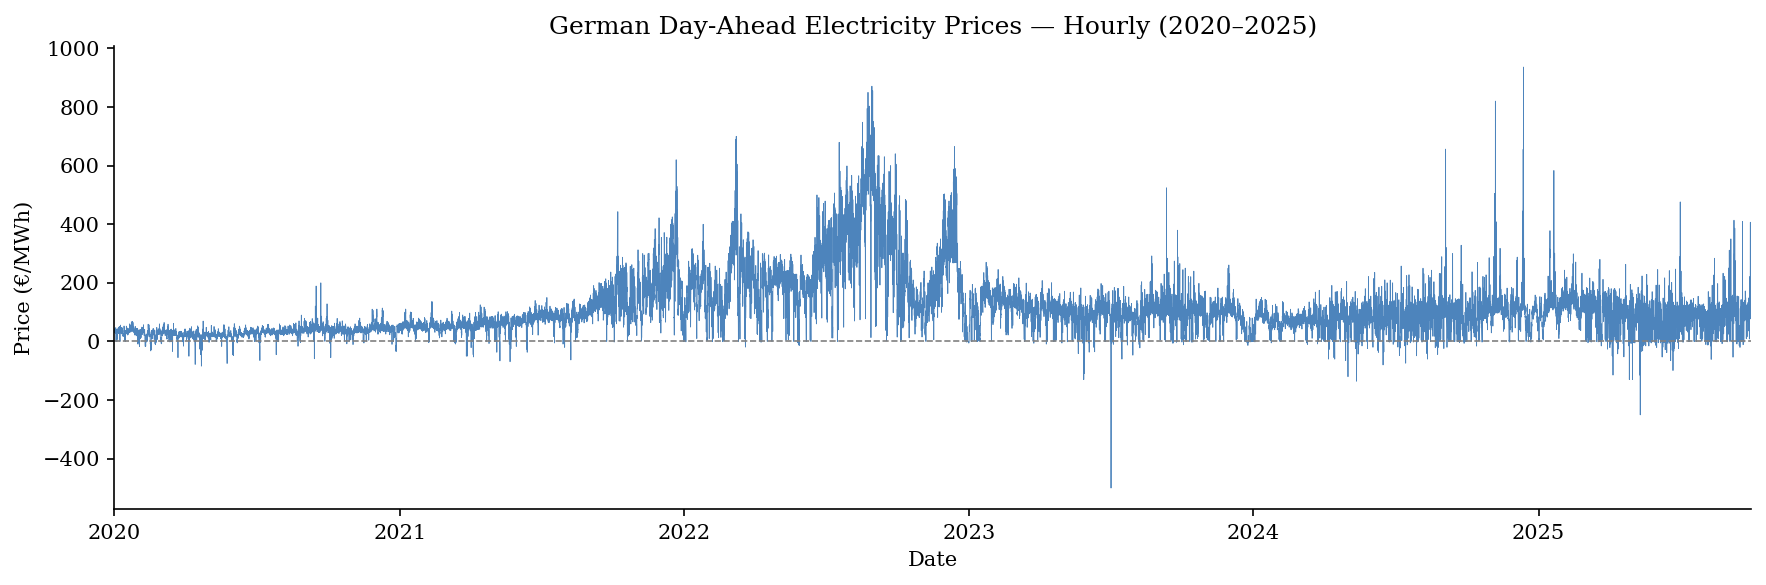

plot_timeseries_hourly.pdf


In [7]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df_h["timestamp"], df_h["price_eur_mwh"], linewidth=0.4, color="#2166ac", alpha=0.8)

#draws a horizontal line across the full plot at y=0
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")

# labels
ax.set_title("German Day-Ahead Electricity Prices — Hourly (2020–2025)", fontsize=12)
ax.set_ylabel("Price (€/MWh)")
ax.set_xlabel("Date")

#show only the year 
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

#fix spacing
plt.tight_layout()

ax.set_xlim([df_h["timestamp"].min(), df_h["timestamp"].max()])
# This forces the axis to end exactly at Sep 30, 2025

#save the plot as PDF file 
plt.savefig("plot_timeseries_hourly.pdf", bbox_inches="tight")

plt.show()
print("plot_timeseries_hourly.pdf")

# Step 8 — Plot 2: Quarter-hourly time series

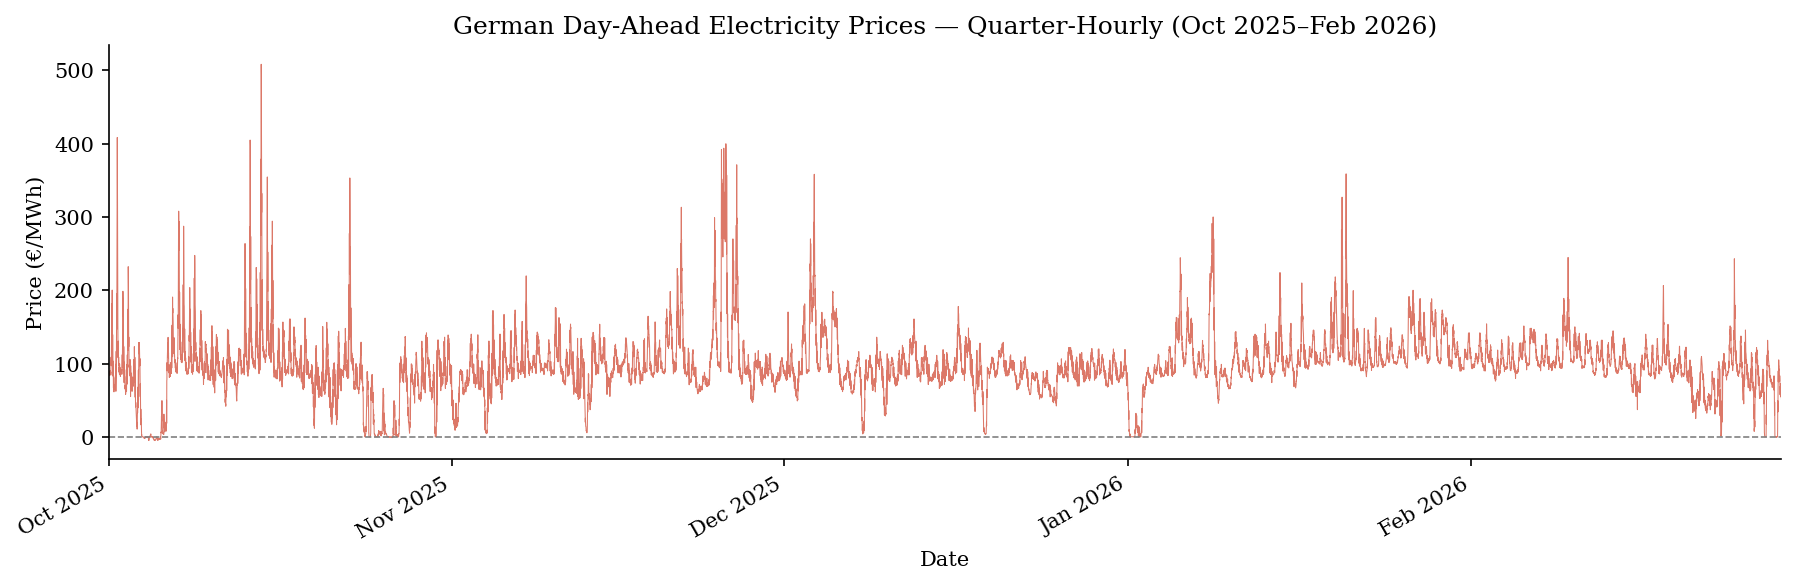

 plot_timeseries_quarterhourly.pdf


In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
                               
ax.plot(df_qh["timestamp"], df_qh["price_eur_mwh"], linewidth=0.5, color="#d6604d", alpha=0.85)

#draws a horizontal line across the full plot at y=0   
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")

#labels
ax.set_title("German Day-Ahead Electricity Prices — Quarter-Hourly (Oct 2025–Feb 2026)", fontsize=12)
ax.set_ylabel("Price (€/MWh)")
ax.set_xlabel("Date")

#shows the month abbreviation + year
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

#fix spacing
fig.autofmt_xdate()
plt.tight_layout()

ax.set_xlim([df_qh["timestamp"].min(), df_qh["timestamp"].max()])
# This forces the axis to end exactly at Feb 28, 2026

#save the plot as PDF file
plt.savefig("plot_timeseries_quarterhourly.pdf", bbox_inches="tight")

    
plt.show()
print(" plot_timeseries_quarterhourly.pdf")

# Step 9 — Plot 3: Price distribution (histogram)

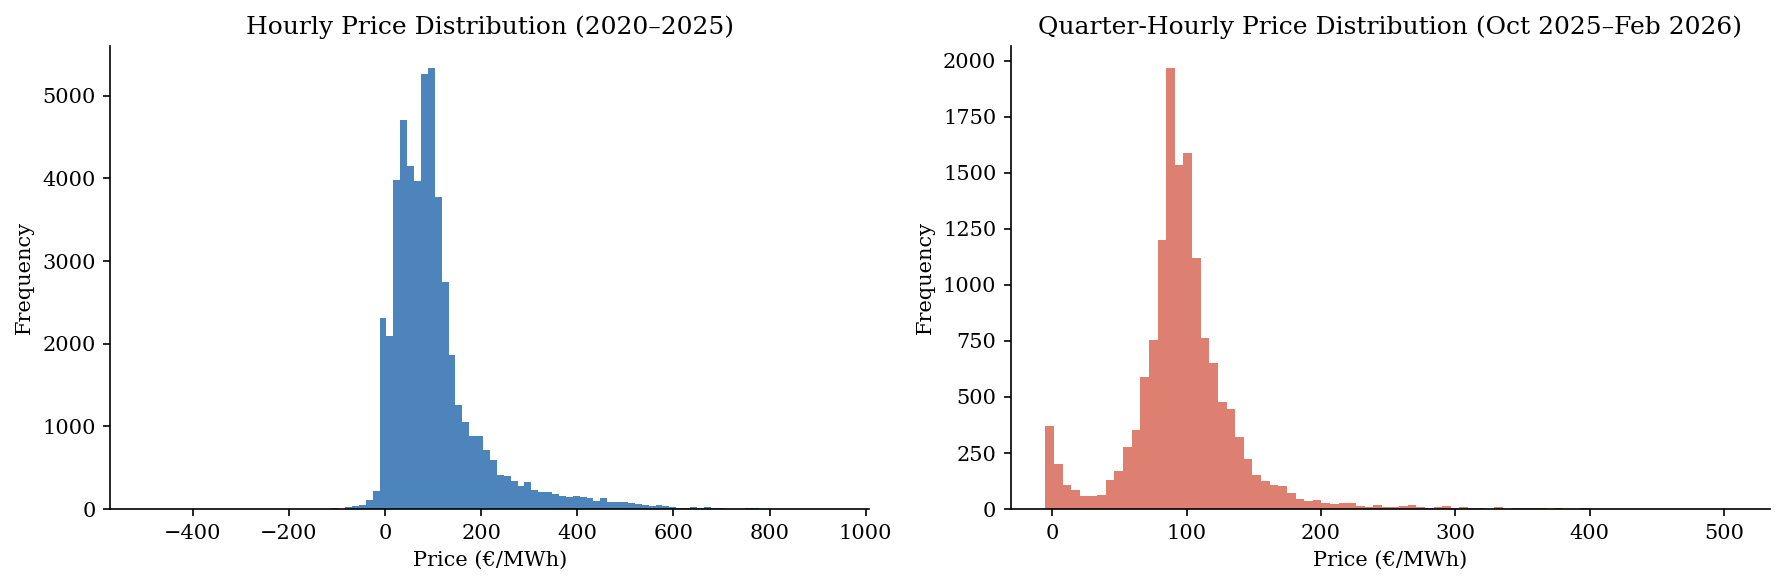

 plot_histograms.pdf


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#plot hourly
axes[0].hist(df_h["price_eur_mwh"], bins=100, color="#2166ac", edgecolor="none", alpha=0.8)
axes[0].set_title("Hourly Price Distribution (2020–2025)")
axes[0].set_xlabel("Price (€/MWh)")
axes[0].set_ylabel("Frequency")

#plot quarter-hourly
axes[1].hist(df_qh["price_eur_mwh"], bins=80, color="#d6604d", edgecolor="none", alpha=0.8)
axes[1].set_title("Quarter-Hourly Price Distribution (Oct 2025–Feb 2026)")
axes[1].set_xlabel("Price (€/MWh)")
axes[1].set_ylabel("Frequency")
 
plt.tight_layout()
plt.savefig("plot_histograms.pdf", bbox_inches="tight")

plt.show()
print(" plot_histograms.pdf")

### Comparison of hourly and quarter-hourly electricity price distributions

The hourly price distribution is right-skewed, with a long tail extending to €900+. Most prices are concentrated between €0 and €200, but the tail tells you extreme price spikes occurred — this was the 2022 energy crisis caused by Russia's invasion of Ukraine.
The left tail going to −€400 shows that negative prices occurred, though rarely. This happens when renewable generation is very high and demand is low — producers pay to offload electricity.
The distribution is also wide and spread out, which matches the high standard deviation of €99 you calculated earlier.

In contrast, the quarter-hourly distribution  is much narrower and taller — most prices are tightly clustered around €80–€120. This means the market was more stable during this short period compared to the turbulent 2020–2025 period.
The tail only reaches €500 and is much thinner — far fewer extreme spikes. The std dev of €43 confirms this visually.
Negative prices still appear on the left but are much smaller in magnitude — only down to around −€5.

# Step 10 — Plot 4: Average intraday profile (quarter-hourly)

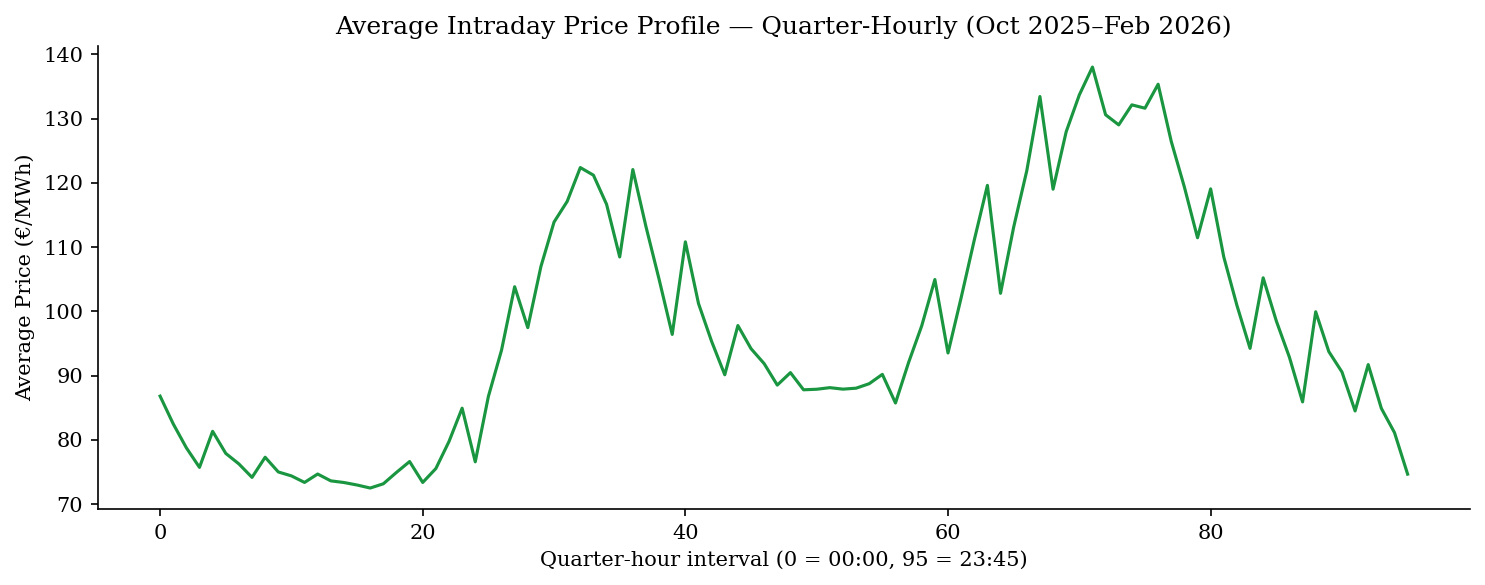

 plot_intraday_profile.pdf


In [10]:
#Create the interval number
df_qh["interval"] = df_qh["timestamp"].dt.hour * 4 + df_qh["timestamp"].dt.minute // 15

#calculate the average price per interval
intraday = df_qh.groupby("interval")["price_eur_mwh"].mean()

#plot it, a-axis is the interval numbers 0 to 95, y-axis is the average price for each interval
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(intraday.index, intraday.values, color="#1a9641", linewidth=1.5)
ax.set_title("Average Intraday Price Profile — Quarter-Hourly (Oct 2025–Feb 2026)")
ax.set_xlabel("Quarter-hour interval (0 = 00:00, 95 = 23:45)")
ax.set_ylabel("Average Price (€/MWh)")

plt.tight_layout()
plt.savefig("plot_intraday_profile.pdf", bbox_inches="tight")

plt.show()
print(" plot_intraday_profile.pdf")

#drop the helper column 
df_qh = df_qh.drop(columns=["interval"])

### Intraday price pattern across the 96 quarter-hourly intervals

**Intervals 0–20 (00:00–05:00) — Night valley**
Prices fall from approximately €87/MWh to around €73/MWh. This marks the lowest 
part of the day, when electricity demand is minimal because most households and 
businesses are inactive.

**Intervals 20–35 (05:00–08:45) — Morning ramp-up**
Prices rise sharply from around €73/MWh to approximately €122/MWh. This period 
reflects the morning increase in demand as households wake up and commercial and 
industrial activity begins.

**Intervals 35–50 (08:45–12:30) — Midday dip**
Prices decline again to around €88/MWh. A likely explanation is the increasing 
availability of solar generation during the late morning, which adds supply and 
puts downward pressure on prices.

**Intervals 50–68 (12:30–17:00) — Afternoon recovery**
Prices gradually increase to approximately €119/MWh as solar generation starts 
to weaken later in the day.

**Intervals 68–76 (17:00–19:00) — Evening peak**
This is the highest-price period of the day, reaching around €138/MWh. At this 
time, solar generation has largely disappeared, while household demand rises 
again in the evening.

**Intervals 76–95 (19:00–23:45) — Evening decline**
Prices decrease steadily back to around €75/MWh as demand falls during the late 
evening and nighttime hours.

# Step 11 — Save clean CSV files

In [11]:
df_h.to_csv("../data/clean/day_ahead_hourly_clean.csv", index=False)
df_qh.to_csv("../data/clean/day_ahead_quarterhourly_clean.csv", index=False)
 
print("Saved clean files:")
print("  day_ahead_hourly_clean.csv       —", len(df_h), "rows")
print("  day_ahead_quarterhourly_clean.csv —", len(df_qh), "rows")

Saved clean files:
  day_ahead_hourly_clean.csv       — 50394 rows
  day_ahead_quarterhourly_clean.csv — 14496 rows
